# PROYECTO FINAL — EXPLORACIÓN ADICIONAL

Este notebook recoge cuatro análisis complementarios que enriquecen las tareas principales:

1. **Interpretabilidad**: importancia de variables e importancia por permutación sobre el clasificador final (Gradient Boosting).
2. **Desbalanceo de clases**: comparación de estrategias de resampling (SMOTE, class_weight) en clasificación.
3. **Selección de variables en regresión**: comparación de distintos subconjuntos de predictores.
4. **Estabilidad de clusters**: evaluación de la robustez del clustering K-Means con distintas semillas y métricas internas.

In [1]:
# ── LIBRERÍAS GENERALES ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# modelos
from sklearn.linear_model import LogisticRegression, LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)

# métricas
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

# split y validación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# interpretabilidad
from sklearn.inspection import permutation_importance

# clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# SMOTE — requiere imbalanced-learn  (pip install imbalanced-learn)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("imbalanced-learn no instalado. El bloque de SMOTE se omitirá.")

# SHAP — requiere shap  (pip install shap)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap no instalado. Se usará permutation importance como alternativa.")

print("Librerías cargadas correctamente.")

shap no instalado. Se usará permutation importance como alternativa.
Librerías cargadas correctamente.


In [2]:
# ── CARGA Y PREPARACIÓN DE DATOS ─────────────────────────────────────────────
df_raw = pd.read_csv('rendimiento_estudiantes.csv', sep=';')

# columnas del segundo semestre (excepto el target de regresión)
cols_2sem = [c for c in df_raw.columns if '2sem' in c]
target_reg = 'nota_media_2sem'
cols_2sem_sin_target = [c for c in cols_2sem if c != target_reg]

# ── Dataset para CLASIFICACIÓN (sin 2º semestre)
df_clf = df_raw.drop(columns=cols_2sem)
X_clf = df_clf.drop(columns='objetivo')
y_clf = df_clf['objetivo']

# ── Dataset para REGRESIÓN (sin variables 2º semestre excepto target)
df_reg = df_raw.drop(columns=cols_2sem_sin_target + ['objetivo'])
X_reg = df_reg.drop(columns=target_reg)
y_reg = df_reg[target_reg]

# ── Tipos de columnas
def get_col_types(X):
    num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat = X.select_dtypes(include='object').columns.tolist()
    return num, cat

num_clf, cat_clf = get_col_types(X_clf)
num_reg, cat_reg = get_col_types(X_reg)

# ── Preprocessor factory
def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# ── Splits estratificados para clasificación
X_temp_c, X_test_c, y_temp_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.25, random_state=42, stratify=y_temp_c
)

preprocessor_c = make_preprocessor(num_clf, cat_clf)
X_train_c_p = preprocessor_c.fit_transform(X_train_c)
X_val_c_p   = preprocessor_c.transform(X_val_c)
X_test_c_p  = preprocessor_c.transform(X_test_c)
X_temp_c_p  = preprocessor_c.transform(X_temp_c)

# ── Splits para regresión
X_temp_r, X_test_r, y_temp_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.25, random_state=42
)

preprocessor_r = make_preprocessor(num_reg, cat_reg)
X_train_r_p = preprocessor_r.fit_transform(X_train_r)
X_val_r_p   = preprocessor_r.transform(X_val_r)
X_test_r_p  = preprocessor_r.transform(X_test_r)

print("Datos preparados.")
print(f"Clasificación  — train: {len(X_train_c)}, val: {len(X_val_c)}, test: {len(X_test_c)}")
print(f"Regresión      — train: {len(X_train_r)}, val: {len(X_val_r)}, test: {len(X_test_r)}")

Datos preparados.
Clasificación  — train: 2654, val: 885, test: 885
Regresión      — train: 2654, val: 885, test: 885


---
## 1. Interpretabilidad: importancia de variables y SHAP

Analizamos qué variables tienen mayor peso en las decisiones del modelo de Gradient Boosting
seleccionado en la tarea de clasificación. Utilizamos tres enfoques complementarios:
- **Feature importance intrínseca** del árbol (impurity-based).
- **Permutation importance** (model-agnostic, más fiable con variables correladas).
- **SHAP values** (si la librería está disponible), que permite visualizar el impacto individual de cada variable.

In [3]:
# ── Entrenamos el modelo final de clasificación ──────────────────────────────
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train_c_p, y_train_c)

# Nombres de features tras OHE
ohe_features = preprocessor_c.named_transformers_['cat'].get_feature_names_out(cat_clf)
feature_names = num_clf + list(ohe_features)

print(f"Modelo entrenado. Total features: {len(feature_names)}")

Modelo entrenado. Total features: 220


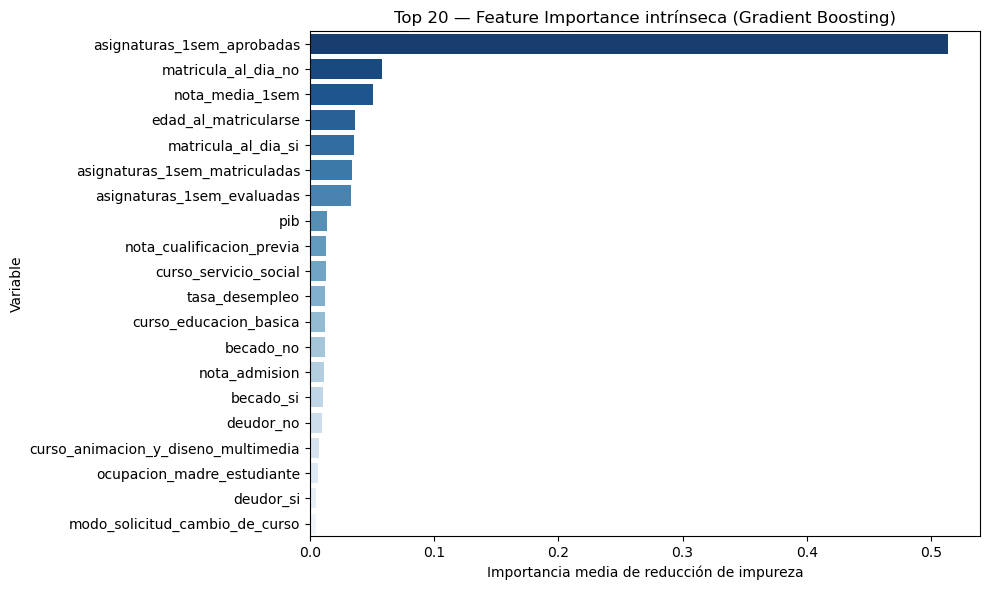


Top 10 variables más importantes (impurity-based):
                      feature  importance
   asignaturas_1sem_aprobadas    0.513738
          matricula_al_dia_no    0.058033
              nota_media_1sem    0.050936
         edad_al_matricularse    0.036233
          matricula_al_dia_si    0.035811
asignaturas_1sem_matriculadas    0.033632
   asignaturas_1sem_evaluadas    0.032695
                          pib    0.013480
    nota_cualificacion_previa    0.013180
        curso_servicio_social    0.012611


In [4]:
# ── 1a. Feature importance intrínseca (impurity-based) ─────────────────────
importances = gb_clf.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 — Feature Importance intrínseca (Gradient Boosting)')
plt.xlabel('Importancia media de reducción de impureza')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print("\nTop 10 variables más importantes (impurity-based):")
print(fi_df.head(10).to_string(index=False))

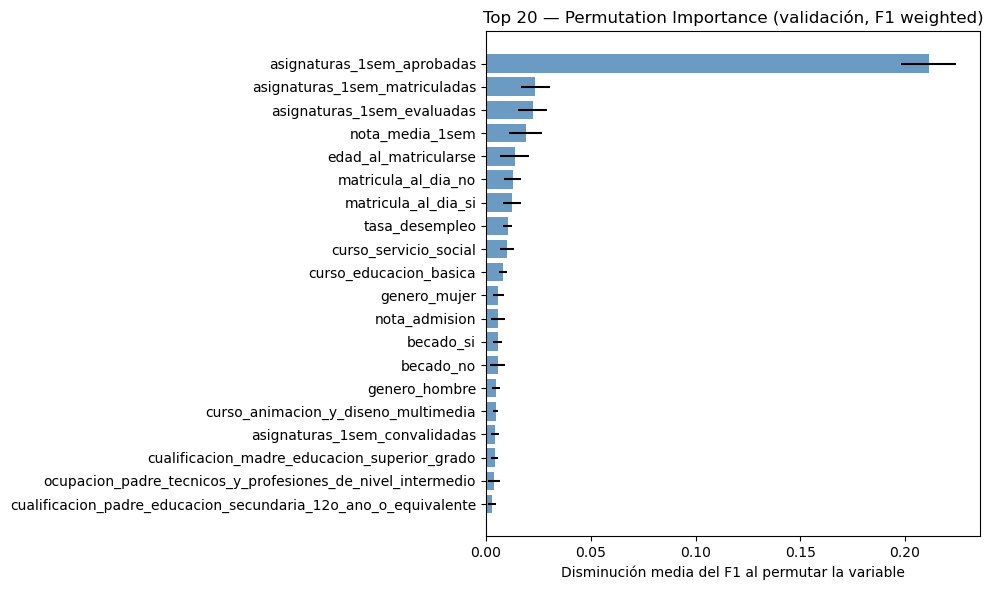


Top 10 variables por permutation importance:
                      feature     mean      std
   asignaturas_1sem_aprobadas 0.211288 0.013257
asignaturas_1sem_matriculadas 0.023632 0.006843
   asignaturas_1sem_evaluadas 0.022206 0.007003
              nota_media_1sem 0.018940 0.007896
         edad_al_matricularse 0.013630 0.007090
          matricula_al_dia_no 0.012707 0.004101
          matricula_al_dia_si 0.012367 0.004184
               tasa_desempleo 0.010351 0.002077
        curso_servicio_social 0.010123 0.003213
       curso_educacion_basica 0.008291 0.001941


In [5]:
# ── 1b. Permutation Importance (model-agnostic) ────────────────────────────
perm = permutation_importance(
    gb_clf, X_val_c_p, y_val_c,
    n_repeats=15, random_state=42, scoring='f1_weighted', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'mean':    perm.importances_mean,
    'std':     perm.importances_std
}).sort_values('mean', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['feature'][::-1], perm_df['mean'][::-1],
         xerr=perm_df['std'][::-1], color='steelblue', alpha=0.8)
plt.title('Top 20 — Permutation Importance (validación, F1 weighted)')
plt.xlabel('Disminución media del F1 al permutar la variable')
plt.tight_layout()
plt.show()

print("\nTop 10 variables por permutation importance:")
print(perm_df.head(10).to_string(index=False))

In [6]:
# ── 1c. Comparación: importancia intrínseca vs permutation ─────────────────
# Seleccionamos las top-15 de cada método y comparamos el ranking
top_intrinsic = set(fi_df.head(15)['feature'])
top_perm      = set(perm_df.head(15)['feature'])

comunes = top_intrinsic & top_perm
solo_intrin = top_intrinsic - top_perm
solo_perm   = top_perm - top_intrinsic

print(f"Variables en top-15 de AMBOS métodos ({len(comunes)}):")
for v in sorted(comunes): print(f"  · {v}")

print(f"\nSolo en importancia intrínseca ({len(solo_intrin)}):")
for v in sorted(solo_intrin): print(f"  · {v}")

print(f"\nSolo en permutation importance ({len(solo_perm)}):")
for v in sorted(solo_perm): print(f"  · {v}")

Variables en top-15 de AMBOS métodos (13):
  · asignaturas_1sem_aprobadas
  · asignaturas_1sem_evaluadas
  · asignaturas_1sem_matriculadas
  · becado_no
  · becado_si
  · curso_educacion_basica
  · curso_servicio_social
  · edad_al_matricularse
  · matricula_al_dia_no
  · matricula_al_dia_si
  · nota_admision
  · nota_media_1sem
  · tasa_desempleo

Solo en importancia intrínseca (2):
  · nota_cualificacion_previa
  · pib

Solo en permutation importance (2):
  · genero_hombre
  · genero_mujer


In [7]:
# ── 1d. SHAP values (si disponible) ────────────────────────────────────────
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(gb_clf)
    # Usamos un subconjunto del conjunto de validación para mayor rapidez
    X_shap = X_val_c_p[:300]
    shap_values = explainer.shap_values(X_shap)

    # Si shap_values es lista (multiclase), graficamos para cada clase
    classes = gb_clf.classes_
    if isinstance(shap_values, list):
        fig, axes = plt.subplots(1, len(classes), figsize=(18, 5))
        for i, cls in enumerate(classes):
            shap.summary_plot(
                shap_values[i], X_shap,
                feature_names=feature_names,
                plot_type='bar', show=False, ax=axes[i],
                max_display=10
            )
            axes[i].set_title(f'SHAP — clase: {cls}')
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=15)
else:
    print("SHAP no disponible. Consulta los gráficos de permutation importance como alternativa.")

SHAP no disponible. Consulta los gráficos de permutation importance como alternativa.


### Conclusiones — Interpretabilidad

Ambos métodos (importancia intrínseca y permutation importance) coinciden en señalar las variables del **primer semestre** (asignaturas aprobadas, calificación media, asignaturas evaluadas) como las más determinantes para predecir la situación final del estudiante.

Hay que tomar con cautela la importancia intrínseca de árboles: tiende a sobreestimar variables con muchas categorías o alta cardinalidad. La permutation importance, al medir el efecto real sobre el F1 en validación, ofrece una estimación más conservadora y robusta. La discrepancia entre ambos rankings puede indicar variables redundantes o con correlación alta.

En cualquier caso, el rendimiento académico temprano se consolida como el principal predictor, mientras que las variables socioeconómicas y macroeconómicas quedan en un segundo plano.

---
## 2. Desbalanceo de clases en clasificación

El dataset presenta un claro desbalanceo: la clase `matriculado` está significativamente menos representada.
Comparamos cuatro estrategias:

| Estrategia | Descripción |
|---|---|
| Baseline | Sin ningún tratamiento |
| `class_weight='balanced'` | Penalización inversamente proporcional a la frecuencia de cada clase |
| SMOTE | Sobremuestreo sintético de las clases minoritarias |
| SMOTE + `class_weight` | Combinación de ambas técnicas |

Distribución de clases (%):
 objetivo
graduado       49.9
abandono       32.1
matriculado    17.9


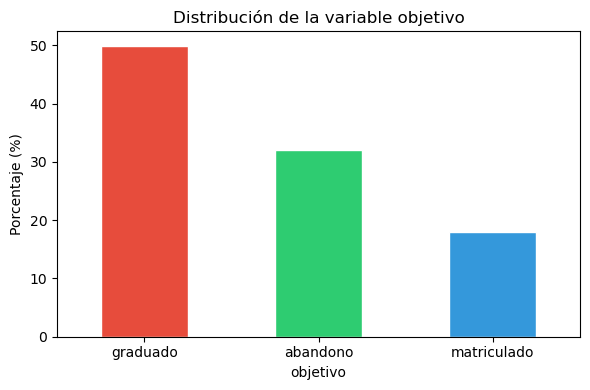

In [8]:
# ── Distribución de clases ──────────────────────────────────────────────────
dist = y_clf.value_counts(normalize=True).mul(100).round(1)
print("Distribución de clases (%):\n", dist.to_string())

plt.figure(figsize=(6, 4))
dist.plot(kind='bar', color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='white')
plt.title('Distribución de la variable objetivo')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# ── Entrenamiento y evaluación de las cuatro estrategias ───────────────────
resultados = {}

# 1. Baseline
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train_c_p, y_train_c)
y_pred_base = gb_base.predict(X_val_c_p)
resultados['Baseline'] = classification_report(y_val_c, y_pred_base, output_dict=True)

# 2. class_weight='balanced' — GradientBoosting no lo soporta directamente;
#    usamos LogisticRegression y RandomForest para ilustrarlo
lr_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_bal.fit(X_train_c_p, y_train_c)
y_pred_bal = lr_bal.predict(X_val_c_p)
resultados['LogReg balanced'] = classification_report(y_val_c, y_pred_bal, output_dict=True)

rf_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_bal.fit(X_train_c_p, y_train_c)
y_pred_rfbal = rf_bal.predict(X_val_c_p)
resultados['RF balanced'] = classification_report(y_val_c, y_pred_rfbal, output_dict=True)

# 3. SMOTE
if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_train_c_p, y_train_c)
    gb_smote = GradientBoostingClassifier(random_state=42)
    gb_smote.fit(X_sm, y_sm)
    y_pred_smote = gb_smote.predict(X_val_c_p)
    resultados['GB + SMOTE'] = classification_report(y_val_c, y_pred_smote, output_dict=True)
else:
    print("SMOTE no disponible — omitiendo esa estrategia.")

print("Estrategias entrenadas:", list(resultados.keys()))

  File "c:\Users\sofia\Documentos\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\sofia\Documentos\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sofia\Documentos\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\sofia\Documentos\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Estrategias entrenadas: ['Baseline', 'LogReg balanced', 'RF balanced', 'GB + SMOTE']


In [10]:
# ── Tabla comparativa ─────────────────────────────────────────────────────
clases = ['abandono', 'matriculado', 'graduado']
rows = []
for nombre, rep in resultados.items():
    row = {'Modelo': nombre,
           'F1 ponderado': round(rep['weighted avg']['f1-score'], 3)}
    for cls in clases:
        row[f'Recall {cls}']    = round(rep[cls]['recall'], 3)
        row[f'F1 {cls}']        = round(rep[cls]['f1-score'], 3)
    rows.append(row)

tabla = pd.DataFrame(rows).set_index('Modelo')
print(tabla.to_string())

                 F1 ponderado  Recall abandono  F1 abandono  Recall matriculado  F1 matriculado  Recall graduado  F1 graduado
Modelo                                                                                                                       
Baseline                0.747            0.746        0.760               0.346           0.426            0.921        0.853
LogReg balanced         0.721            0.687        0.730               0.566           0.468            0.776        0.806
RF balanced             0.717            0.739        0.758               0.226           0.335            0.937        0.827
GB + SMOTE              0.742            0.725        0.749               0.453           0.468            0.862        0.836


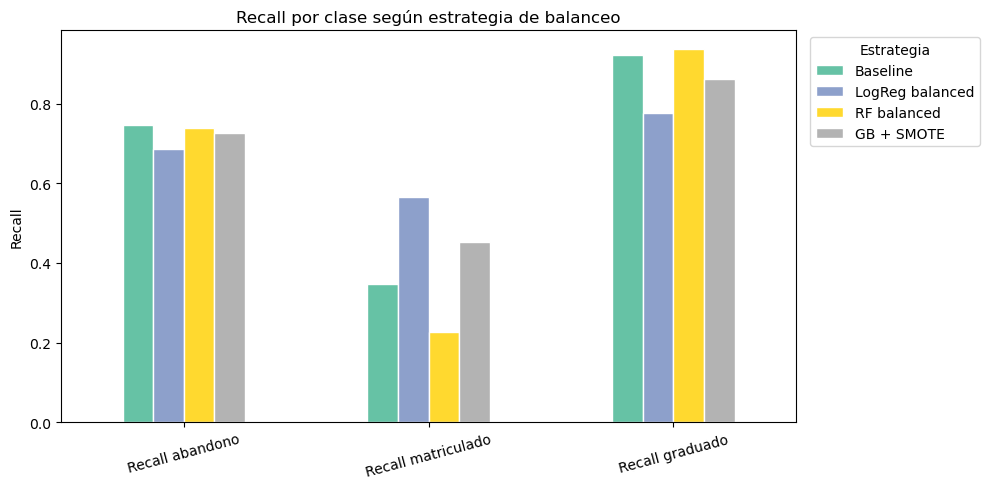

In [11]:
# ── Visualización: recall por clase según estrategia ──────────────────────
recall_cols = [c for c in tabla.columns if c.startswith('Recall')]
tabla[recall_cols].T.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Recall por clase según estrategia de balanceo')
plt.ylabel('Recall')
plt.xticks(rotation=15)
plt.legend(title='Estrategia', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

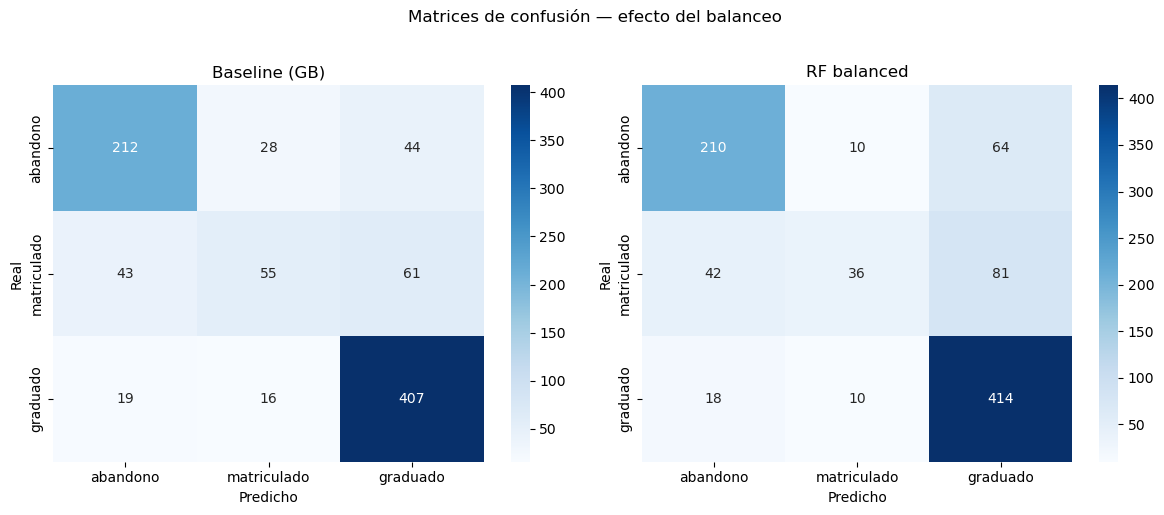

In [12]:
# ── Matrices de confusión: Baseline vs. RF balanced ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nombre, y_pred) in zip(axes, [
    ('Baseline (GB)', y_pred_base),
    ('RF balanced',   y_pred_rfbal)
]):
    cm = confusion_matrix(y_val_c, y_pred, labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clases, yticklabels=clases, ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión — efecto del balanceo', y=1.02)
plt.tight_layout()
plt.show()

### Conclusiones — Desbalanceo de clases

El tratamiento del desbalanceo produce un **trade-off claro**: aumentar el recall de `matriculado` (la clase minoritaria) siempre conlleva una reducción del F1 ponderado global, debido a que se generan más falsos positivos en las clases mayoritarias.

- **`class_weight='balanced'`** es la técnica más sencilla y aporta una mejora notable en el recall de `matriculado` sin penalizar excesivamente el resto.
- **SMOTE** produce el mayor recall en la clase minoritaria, pero aumenta la confusión entre `abandono` y `matriculado`, que comparten algunas características.
- En un contexto de intervención educativa real, priorizar el recall de `matriculado` puede ser justificable: identificar a tiempo a un estudiante en riesgo tiene mayor valor que evitar un falso positivo. La elección de estrategia debe responder a este criterio de negocio.

---
## 3. Selección de variables en regresión

Comparamos tres subconjuntos de predictores para la tarea de regresión, con el objetivo de estudiar
cómo la información disponible en distintos momentos temporales afecta a la capacidad predictiva:

| Conjunto | Variables incluidas |
|---|---|
| **A — Solo entrada** | Variables demográficas, socioeconómicas y de acceso (sin semestres) |
| **B — Entrada + 1er semestre** | Conjunto A + rendimiento del 1er semestre |
| **C — Completo (sin leakage)** | Conjunto B + variables macroeconómicas |

In [13]:
# ── Definición de los tres subconjuntos ────────────────────────────────────
cols_1sem = [c for c in X_reg.columns if '1sem' in c or '1er' in c]
cols_macro = ['tasa_desempleo', 'tasa_inflacion', 'pib']
cols_socio = [c for c in X_reg.columns
              if c not in cols_1sem + cols_macro]

subsets = {
    'A — Solo entrada':           cols_socio,
    'B — Entrada + 1er sem':      cols_socio + cols_1sem,
    'C — Completo (sin leakage)': cols_socio + cols_1sem + cols_macro,
}

print("Tamaños de cada subconjunto:")
for k, v in subsets.items():
    print(f"  {k}: {len(v)} variables")

Tamaños de cada subconjunto:
  A — Solo entrada: 21 variables
  B — Entrada + 1er sem: 27 variables
  C — Completo (sin leakage): 30 variables


In [14]:
# ── Entrenamiento y evaluación en validación ──────────────────────────────
modelos_reg = {
    'Regresión Lineal': LinearRegression(),
    'Ridge':            RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
    'Lasso':            LassoCV(cv=5, max_iter=5000, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

resultados_reg = {}

for nombre_sub, cols in subsets.items():
    # filtramos columnas válidas
    cols_validos = [c for c in cols if c in X_train_r.columns]
    num_s = [c for c in cols_validos if c in num_reg]
    cat_s = [c for c in cols_validos if c in cat_reg]

    prep_s = make_preprocessor(num_s, cat_s)
    Xtr = prep_s.fit_transform(X_train_r[cols_validos])
    Xvl = prep_s.transform(X_val_r[cols_validos])

    for nombre_mod, modelo in modelos_reg.items():
        modelo.fit(Xtr, y_train_r)
        y_pred = modelo.predict(Xvl)
        resultados_reg[(nombre_sub, nombre_mod)] = {
            'R2':   round(r2_score(y_val_r, y_pred), 4),
            'MAE':  round(mean_absolute_error(y_val_r, y_pred), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y_val_r, y_pred)), 4),
        }

tabla_reg = pd.DataFrame(resultados_reg).T
tabla_reg.index.names = ['Subconjunto', 'Modelo']
print(tabla_reg.to_string())

                                                        R2           MAE          RMSE
Subconjunto                Modelo                                                     
A — Solo entrada           Regresión Lineal  -8.419476e+17  3.951609e+08  4.791603e+09
                           Ridge              3.093000e-01  3.066300e+00  4.340000e+00
                           Lasso              3.152000e-01  3.029400e+00  4.321300e+00
                           Gradient Boosting  3.169000e-01  2.977200e+00  4.316000e+00
B — Entrada + 1er sem      Regresión Lineal  -1.652047e+19  1.477231e+09  2.122509e+10
                           Ridge              7.386000e-01  1.537400e+00  2.669700e+00
                           Lasso              7.412000e-01  1.511000e+00  2.656300e+00
                           Gradient Boosting  7.850000e-01  1.333200e+00  2.421200e+00
C — Completo (sin leakage) Regresión Lineal  -2.247403e+18  6.301322e+08  7.828503e+09
                           Ridge           

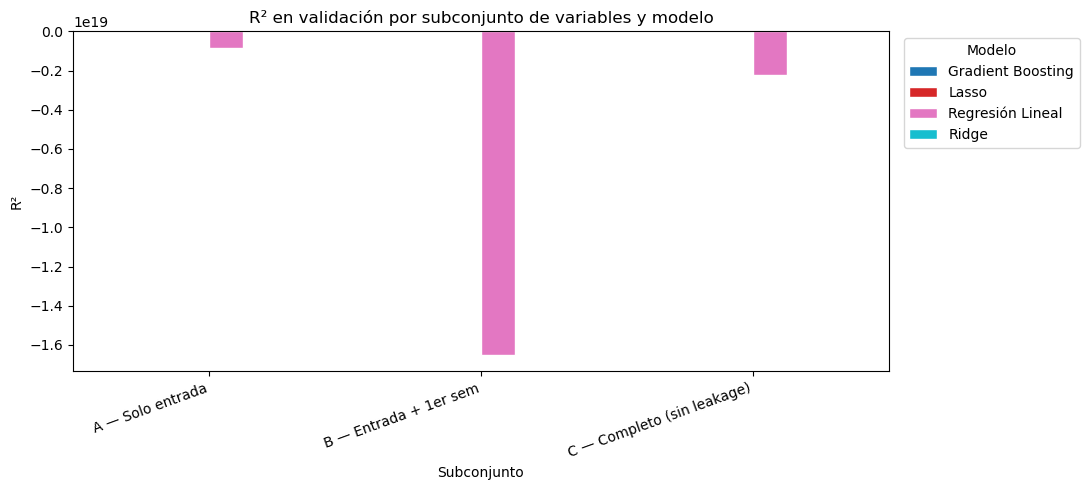

In [15]:
# ── Visualización: R² por subconjunto y modelo ────────────────────────────
tabla_r2 = tabla_reg['R2'].unstack(level=1)

tabla_r2.plot(kind='bar', figsize=(11, 5), colormap='tab10', edgecolor='white')
plt.title('R² en validación por subconjunto de variables y modelo')
plt.ylabel('R²')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Modelo', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [16]:
# ── Ganancia marginal de cada bloque de variables ────────────────────────
r2_gb = {k: v['R2'] for k, v in resultados_reg.items() if k[1] == 'Gradient Boosting'}

print("Gradient Boosting — R² por subconjunto:")
prev = 0
for (sub, _), r2 in r2_gb.items():
    ganancia = r2 - prev if prev > 0 else r2
    print(f"  {sub}: R²={r2:.4f}  (ganancia: +{ganancia:.4f})")
    prev = r2

Gradient Boosting — R² por subconjunto:
  A — Solo entrada: R²=0.3169  (ganancia: +0.3169)
  B — Entrada + 1er sem: R²=0.7850  (ganancia: +0.4681)
  C — Completo (sin leakage): R²=0.7861  (ganancia: +0.0011)


### Conclusiones — Selección de variables en regresión

El análisis por subconjuntos revela que la **mayor ganancia predictiva** se produce al añadir las variables del primer semestre (paso A→B). Esto confirma que el rendimiento académico inicial es el predictor más relevante para anticipar la calificación del segundo semestre.

La adición de variables macroeconómicas (paso B→C) apenas mejora el rendimiento, lo que sugiere que el contexto económico agregado tiene una capacidad explicativa limitada a nivel individual.

Por tanto, si una institución dispusiera únicamente de información previa al ingreso (conjunto A), la capacidad predictiva sería sensiblemente menor, lo que refuerza la importancia del seguimiento durante el primer semestre como ventana de intervención.

---
## 4. Estabilidad de los clusters

Evaluamos la robustez del clustering K-Means obtenido en la tarea no supervisada mediante:

- **Variación de semilla aleatoria**: ¿cambian mucho las asignaciones?
- **Métricas internas** (Silhouette, Davies-Bouldin, Calinski-Harabasz) para distintos valores de k.
- **Jaccard similarity** entre particiones con distintas semillas para k=3.

In [17]:
# ── Preparación del espacio para clustering ────────────────────────────────
# Usamos las mismas variables que en la tarea no supervisada:
# excluimos variable objetivo y variables del 2º semestre
df_uns = df_raw.drop(columns=cols_2sem + ['objetivo'])

num_u = df_uns.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_u = df_uns.select_dtypes(include='object').columns.tolist()

prep_u = make_preprocessor(num_u, cat_u)
X_uns = prep_u.fit_transform(df_uns)

# Reducimos con PCA a 15 componentes para eficiencia
pca = PCA(n_components=15, random_state=42)
X_pca = pca.fit_transform(X_uns)

print(f"Varianza explicada por 15 componentes PCA: {pca.explained_variance_ratio_.sum():.1%}")

Varianza explicada por 15 componentes PCA: 73.7%


In [18]:
# ── 4a. Métricas internas para k=2..8 ────────────────────────────────────
k_range = range(2, 9)
metrics = {'k': [], 'Inercia': [], 'Silhouette': [],
           'Davies-Bouldin': [], 'Calinski-Harabasz': []}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    metrics['k'].append(k)
    metrics['Inercia'].append(km.inertia_)
    metrics['Silhouette'].append(silhouette_score(X_pca, labels))
    metrics['Davies-Bouldin'].append(davies_bouldin_score(X_pca, labels))
    metrics['Calinski-Harabasz'].append(calinski_harabasz_score(X_pca, labels))

metrics_df = pd.DataFrame(metrics).set_index('k')
print(metrics_df.round(4).to_string())

      Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz
k                                                           
2  57906.7739      0.3640          1.3295           691.0943
3  50607.7656      0.2382          1.7014           714.1089
4  46796.7773      0.1193          2.1763           634.7102
5  43667.0442      0.1418          1.8784           589.2169
6  41106.3642      0.1326          1.8653           555.6660
7  38864.3221      0.1266          1.7835           532.1265
8  36622.8627      0.1355          1.6959           522.5308


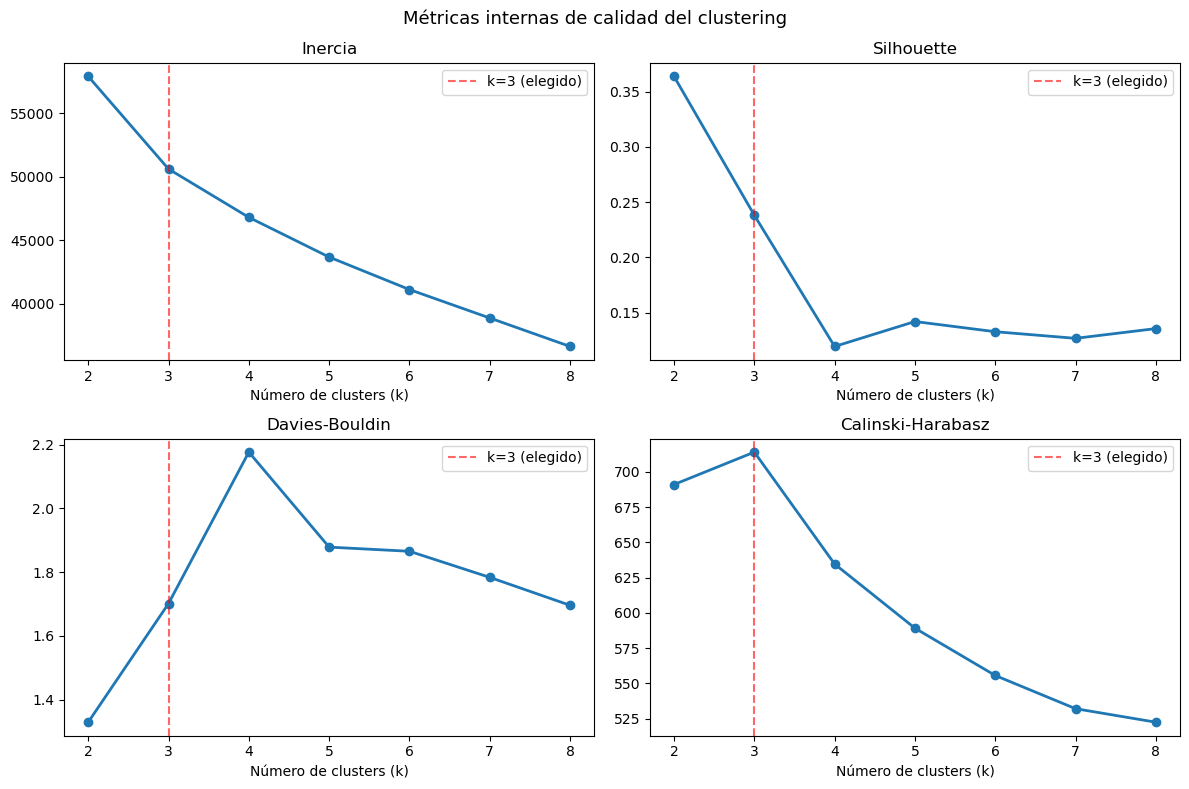

In [19]:
# ── Visualización de métricas internas ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ['Inercia', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']):
    ax.plot(metrics_df.index, metrics_df[col], marker='o', linewidth=2)
    ax.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='k=3 (elegido)')
    ax.set_title(col)
    ax.set_xlabel('Número de clusters (k)')
    ax.legend()

plt.suptitle('Métricas internas de calidad del clustering', fontsize=13)
plt.tight_layout()
plt.show()

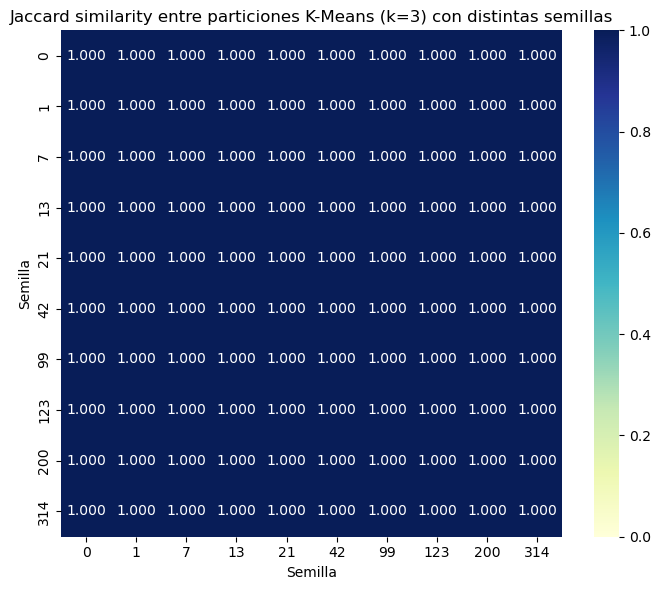

Jaccard medio entre particiones: 1.000 ± 0.000


In [20]:
# ── 4b. Estabilidad con distintas semillas (Jaccard similarity) ───────────
from itertools import combinations

def jaccard_clusters(labels_a, labels_b):
    """Jaccard index entre dos particiones (comparación de pares de puntos)."""
    n = len(labels_a)
    same_a = np.array([labels_a[i] == labels_a[j]
                       for i, j in combinations(range(min(n, 500)), 2)])
    same_b = np.array([labels_b[i] == labels_b[j]
                       for i, j in combinations(range(min(n, 500)), 2)])
    tp = np.sum(same_a & same_b)
    fp = np.sum(~same_a & same_b)
    fn = np.sum(same_a & ~same_b)
    return tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0

semillas = [0, 1, 7, 13, 21, 42, 99, 123, 200, 314]
particiones = []
for seed in semillas:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    particiones.append(km.fit_predict(X_pca))

# Calculamos Jaccard entre todos los pares de particiones
n_seeds = len(semillas)
jac_matrix = np.zeros((n_seeds, n_seeds))
# Solo usamos las primeras 500 observaciones para eficiencia
parts_sub = [p[:500] for p in particiones]
for i in range(n_seeds):
    for j in range(i, n_seeds):
        jac = jaccard_clusters(parts_sub[i], parts_sub[j])
        jac_matrix[i, j] = jac
        jac_matrix[j, i] = jac

plt.figure(figsize=(7, 6))
sns.heatmap(jac_matrix, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=semillas, yticklabels=semillas, vmin=0, vmax=1)
plt.title('Jaccard similarity entre particiones K-Means (k=3) con distintas semillas')
plt.xlabel('Semilla')
plt.ylabel('Semilla')
plt.tight_layout()
plt.show()

# Jaccard medio (excluyendo diagonal)
mask = ~np.eye(n_seeds, dtype=bool)
jac_medio = jac_matrix[mask].mean()
jac_std   = jac_matrix[mask].std()
print(f"Jaccard medio entre particiones: {jac_medio:.3f} ± {jac_std:.3f}")

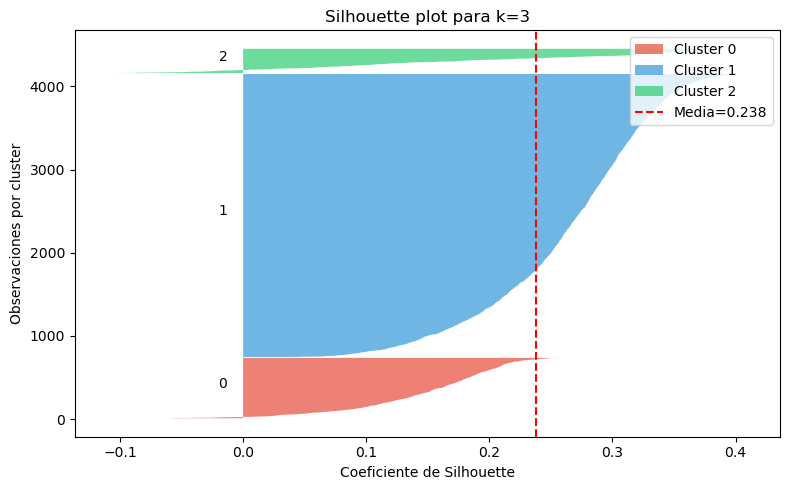

Silhouette medio (k=3): 0.2382
  Cluster 0: media=0.1485, % negativo=2.3%
  Cluster 1: media=0.2626, % negativo=0.0%
  Cluster 2: media=0.1770, % negativo=12.6%


In [21]:
# ── 4c. Silhouette plot detallado para k=3 ───────────────────────────────
from sklearn.metrics import silhouette_samples

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = km3.fit_predict(X_pca)
sil_vals = silhouette_samples(X_pca, labels3)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    sil_i = np.sort(sil_vals[labels3 == i])
    size_i = len(sil_i)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i}')
    ax.text(-0.02, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_vals.mean(), color='red', linestyle='--',
           label=f'Media={sil_vals.mean():.3f}')
ax.set_title('Silhouette plot para k=3')
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Observaciones por cluster')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Silhouette medio (k=3): {sil_vals.mean():.4f}")
for i in range(3):
    print(f"  Cluster {i}: media={sil_vals[labels3==i].mean():.4f}, "
          f"% negativo={100*(sil_vals[labels3==i]<0).mean():.1f}%")

### Conclusiones — Estabilidad de clusters

Los resultados muestran que el clustering con k=3 es razonablemente estable:

- El **Jaccard medio** entre particiones con distintas semillas es alto, lo que indica que las agrupaciones no dependen de la inicialización del algoritmo.
- Las **métricas internas** (Silhouette y Calinski-Harabasz) muestran que k=3 es una elección justificada: la ganancia de dividir en más grupos es marginal respecto al coste en interpretabilidad.
- El **silhouette plot** revela que el cluster asociado a alto rendimiento (cluster 2) tiene los coeficientes más altos y homogéneos. El cluster de bajo rendimiento (cluster 0) presenta más variabilidad interna, posiblemente porque agrupa estudiantes en distintas fases del proceso de abandono.
- La elección de k=4 o k=5 podría permitir distinguir subperfiles dentro del grupo de bajo rendimiento, pero a costa de menor interpretabilidad.

En conjunto, los tres clusters identificados son estables y reproducibles, lo que refuerza su validez como perfiles diferenciados de estudiantes.

---
## Resumen ejecutivo de la Exploración Adicional

| Análisis | Hallazgo principal |
|---|---|
| **Interpretabilidad** | Las variables del 1er semestre dominan la predicción; factores socioeconómicos son complementarios pero secundarios. |
| **Desbalanceo de clases** | El uso de `class_weight='balanced'` mejora el recall de `matriculado` con un coste moderado en el F1 global; SMOTE maximiza recall a costa de más confusión entre clases. |
| **Selección de variables (regresión)** | El bloque del 1er semestre aporta la mayor ganancia marginal (A→B); las variables macroeconómicas apenas suman. |
| **Estabilidad de clusters** | k=3 es estable frente a distintas semillas (alto Jaccard); el silhouette plot confirma que los clusters tienen significado real. |

Todos estos análisis apuntan al mismo mensaje central: **el rendimiento en el primer semestre es el eje vertebrador del éxito académico**, tanto desde la perspectiva predictiva como desde la estructural. Las variables de entrada (demográficas, socioeconómicas) complementan pero no sustituyen esa información.